In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp -r /content/drive/MyDrive/dataset /content/local_dataset

In [3]:
# Notebook implementing the Inception V3 module for further use on the Pet's
# Facial Expression Image dataset
# Implemented module will be built using Pytorch and Keras only
import torch
import tensorflow as tf
import keras as k
from keras.layers import *
from keras.models import Model
import sklearn
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [4]:
# In Inception V3, every convolution layer is followed by Batch Normalization and ReLU
def convolution_batchnorm(x, filters, kernel_size, padding='same', strides=1):
  x = Conv2D(filters, kernel_size, strides=strides, padding=padding)(x)
  x = BatchNormalization(axis=3, scale=False)(x)
  x = Activation('relu')(x)
  return x

# Inception Block A
def inception_block_a(x):
  # Left hand section
  _1x1 = convolution_batchnorm(x, 64, (1, 1))

  _5x5 = convolution_batchnorm(x, 48, (1, 1))
  _5x5 = convolution_batchnorm(_5x5, 64, (5, 5))

  # Right hand section
  _3x3 = convolution_batchnorm(x, 64, (1, 1))
  _3x3 = convolution_batchnorm(_3x3, 96, (3, 3))
  _3x3 = convolution_batchnorm(_3x3, 96, (3, 3))

  # Pooling layer
  pool = AveragePooling2D((3, 3), strides=(1, 1), padding='same')(x)
  pool = convolution_batchnorm(pool, 32, (1, 1))
  # Concatenate the outputs
  output = concatenate([_1x1, _5x5, _3x3, pool], axis=-1)
  return output

# Reduction Block A
def reduction_block_a(x):
  # Left hand section
  pooling = MaxPooling2D((3, 3), strides=(2, 2), padding='valid')(x)

  _3x3_1 = convolution_batchnorm(x, 384, (3, 3), strides=2, padding='valid')

  # Right hand section
  _3x3_2 = convolution_batchnorm(x, 64, (1, 1))
  _3x3_2 = convolution_batchnorm(_3x3_2, 96, (3, 3))
  _3x3_2 = convolution_batchnorm(_3x3_2, 96, (3, 3), strides=2, padding='valid')

  # Concatenate
  output = concatenate([_3x3_1, _3x3_2, pooling], axis=-1)
  return output

# Inception Block B
def inception_block_b(x):
  _1x1 = convolution_batchnorm(x, 192, (1,1))

  _7x7_1 = convolution_batchnorm(x, 128, (1, 1))
  _7x7_1 = convolution_batchnorm(_7x7_1, 128, (1, 7))
  _7x7_1 = convolution_batchnorm(_7x7_1, 192, (7, 1))

  _7x7_2 = convolution_batchnorm(x, 128, (1, 1))
  _7x7_2 = convolution_batchnorm(_7x7_2, 128, (7, 1))
  _7x7_2 = convolution_batchnorm(_7x7_2, 128, (1, 7))
  _7x7_2 = convolution_batchnorm(_7x7_2, 128, (7, 1))
  _7x7_2 = convolution_batchnorm(_7x7_2, 192, (1, 7))
  # Pooling layer
  pool =  AveragePooling2D((3, 3), strides=(1, 1), padding='same')(x)
  pool = convolution_batchnorm(pool, 192, (1, 1))
  # Concatenate
  output = concatenate([_1x1, _7x7_1, _7x7_2, pool], axis=-1)
  return output

# Reduction Block B
def reduction_block_b(x):
  # Left hand section
  pooling = MaxPooling2D((3, 3), strides=(2, 2), padding='valid')(x)

  _3x3_1 = convolution_batchnorm(x, 192, (1, 1))
  _3x3_1 = convolution_batchnorm(_3x3_1, 320, (3, 3), strides=2, padding='valid')

  # Right hand section
  _3x3_2 = convolution_batchnorm(x, 192, (1, 1))
  _3x3_2 = convolution_batchnorm(_3x3_2, 192, (1,7))
  _3x3_2 = convolution_batchnorm(_3x3_2, 192, (7, 1))
  _3x3_2 = convolution_batchnorm(_3x3_2, 192, (3, 3), strides=2, padding='valid')

  # Concatenate
  output = concatenate([_3x3_1, _3x3_2, pooling], axis=-1)
  return output

# Inception Block C
def inception_block_c(x):
  _1x1 = convolution_batchnorm(x, 320, (1,1))

  _3x3_1 = convolution_batchnorm(x, 384, (1, 1))
  _3x3_1_1 = convolution_batchnorm(_3x3_1, 384, (1, 3))
  _3x3_1_2 = convolution_batchnorm(_3x3_1, 384, (3, 1))
  _3x3_1 = concatenate([_3x3_1_1, _3x3_1_2], axis=-1)

  _3x3_2 = convolution_batchnorm(x, 448, (1, 1))
  _3x3_2 = convolution_batchnorm(_3x3_2, 384, (3, 3))
  _3x3_2_1 = convolution_batchnorm(_3x3_2, 384, (1, 3))
  _3x3_2_2 = convolution_batchnorm(_3x3_2, 384, (3, 1))
  _3x3_2 = concatenate([_3x3_2_1, _3x3_2_2], axis=-1)

  pool = AveragePooling2D((3, 3), strides=(1, 1), padding='same')(x)
  pool = convolution_batchnorm(pool, 192, (1, 1))

  output = concatenate([_1x1, _3x3_1, _3x3_2, pool], axis=-1)
  return output

In [5]:
# Input image 299 x 299 x 3
input_img = Input(shape=(299, 299, 3))
x = convolution_batchnorm(input_img, 32, (3, 3), padding='valid', strides=2)
x = convolution_batchnorm(x, 32, (3, 3), padding='valid')
x = convolution_batchnorm(x, 64, (3, 3))
x = MaxPooling2D((3, 3), strides=(2, 2))(x)
x = convolution_batchnorm(x, 80, (1, 1), padding='valid')
x = convolution_batchnorm(x, 192, (3, 3), padding='valid')
x = MaxPooling2D((3, 3), strides=(2, 2))(x)
# Inception block A, repeated 3 times
x = inception_block_a(x)
x = inception_block_a(x)
x = inception_block_a(x)
# Reduction A
x = reduction_block_a(x)
# Inception block B, repeated 4 times
x = inception_block_b(x)
x = inception_block_b(x)
x = inception_block_b(x)
x = inception_block_b(x)
# Reduction B
x = reduction_block_b(x)
# Inception block C, repeated 2 times
x = inception_block_c(x)
x = inception_block_c(x)
# Global Average Pooling
x = GlobalAveragePooling2D(name='avg_pool')(x)
# 4 main classes in the dataset
classes = 4
predictions = Dense(classes, activation='softmax', name='predictions')(x)

model = Model(inputs=input_img, outputs=predictions, name='inception_v3')
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
model.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,496 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,200 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,432 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 20,037,476 (76.44 MB)

 Trainable params: 20,004,708 (76.31 MB)

 Non-trainable params: 32,768 (128.00 KB)

In [6]:
# Data processing and augmentation
# Loading the dataset
training_data_dir = '/content/local_dataset/train'
validation_data_dir = '/content/local_dataset/valid'
testing_data_dir = '/content/local_dataset/test'

# The training samples will be the only ones augmented, not the valaidation and test
train_data_generation = ImageDataGenerator(rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')
# No augmentation
# train_data_generation = ImageDataGenerator(rescale=1./255)

# Only rescaling
validation_data_generation = ImageDataGenerator(rescale=1./255)
test_data_generation = ImageDataGenerator(rescale=1./255)

batch_size = 32

train_generator = train_data_generation.flow_from_directory(training_data_dir, target_size=(299, 299), batch_size=batch_size, class_mode='categorical')
validation_generator = validation_data_generation.flow_from_directory(validation_data_dir, target_size=(299, 299), batch_size=batch_size, class_mode='categorical', shuffle=False)
test_generator = test_data_generation.flow_from_directory(testing_data_dir, target_size=(299, 299), batch_size=batch_size, class_mode='categorical', shuffle=False)


Found 1000 images belonging to 4 classes.
Found 36 images belonging to 4 classes.
Found 38 images belonging to 4 classes.


In [7]:
# Training the model
history = model.fit(train_generator, epochs=20, validation_data=validation_generator)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 209s 3s/step - accuracy: 0.2690 - loss: 1.7826 - precision: 0.2164 - recall: 0.0290 - val_accuracy: 0.1944 - val_loss: 1.3983 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 872ms/step - accuracy: 0.2780 - loss: 1.4352 - precision: 0.3864 - recall: 0.0170 - val_accuracy: 0.2500 - val_loss: 1.4428 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 906ms/step - accuracy: 0.3250 - loss: 1.4274 - precision: 0.4783 - recall: 0.0330 - val_accuracy: 0.2500 - val_loss: 1.4152 - val_precision: 0.6667 - val_recall: 0.1111
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 886ms/step - accuracy: 0.3440 - loss: 1.3455 - precision: 0.5426 - recall: 0.0510 - val_accuracy: 0.2500 - val_loss: 1.5683 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 870ms/step - accuracy: 0.3430 - loss: 1.3503 - precision: 0.4848 - recall: 0.0480 - val_accu

Evaluating model on test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 10s/step


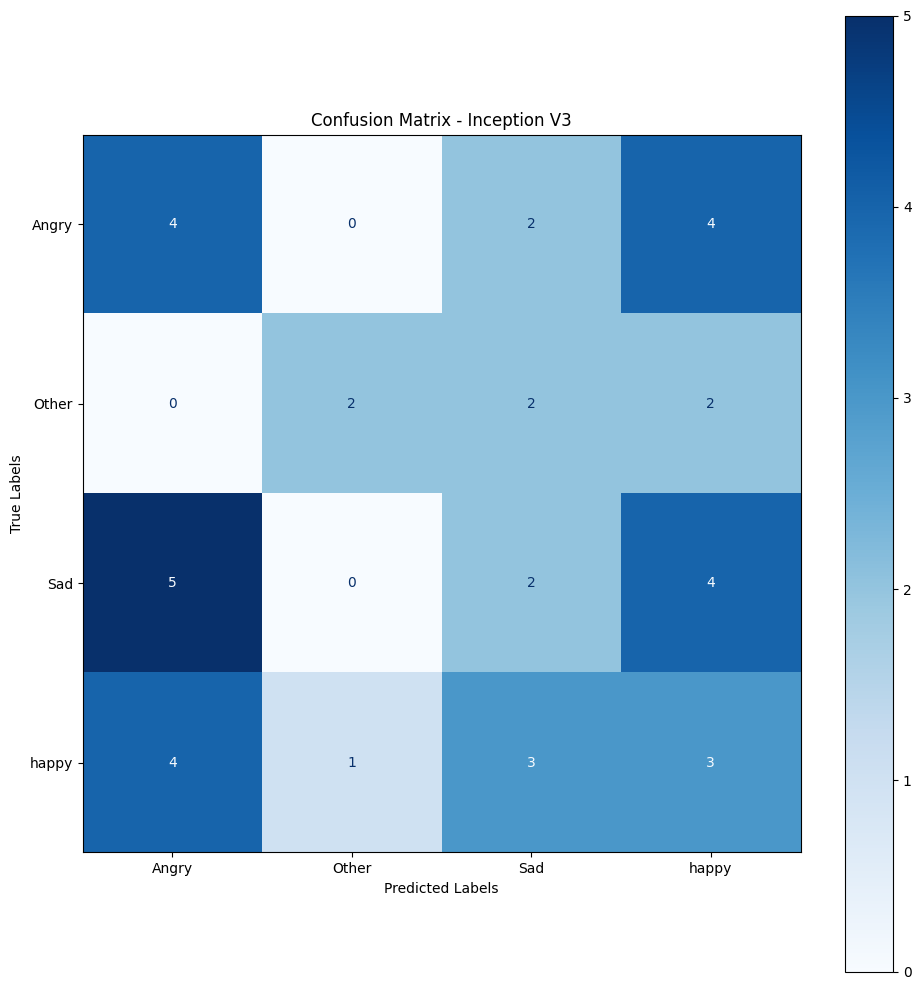

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.40      0.35        10
           1       0.67      0.33      0.44         6
           2       0.22      0.18      0.20        11
           3       0.23      0.27      0.25        11

    accuracy                           0.29        38
   macro avg       0.36      0.30      0.31        38
weighted avg       0.32      0.29      0.29        38



In [8]:
# Evaluate on test set
print('Evaluating model on test set...')
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_predicted = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_predicted)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
figure, ax = plt.subplots(figsize=(10, 10))
display_cm.plot(ax=ax, cmap='Blues', colorbar=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
ax.set_title('Confusion Matrix - Inception V3')
plt.tight_layout()
plt.show()

# Classification report

print("Classification Report:")
print(classification_report(y_true, y_predicted))